# Logistic Regression Sybil Detector — LayerZero

Baseline linear classifier, the paper's configuration, not tuned: L1 penalty, `C=0.01`, `liblinear`, on
standardized features (`sp.LR_PARAMS`, `sp.fit_lr`). Same group split as the tree models.

**Results**: test metrics in section 3, saved to `results/05_logistic_regression_sybil.json`.

## Setup

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import sybil_pipeline as sp
warnings.filterwarnings('ignore')

DATA_DIR = './data'
FEATS = sp.FEATS   # 62 model features (defined in sybil_pipeline.py)

## 1. Data and split

Stratified group split on gas provision trees (49 % train, 21 % validation, 30 % test); the Sybil class is
upsampled to 1:1 in the training partition only.

In [2]:
# ── Feature table (steps 1-7; see 00_data_pipeline) and the stratified group split ──
df, _, _ = sp.build_master_df(DATA_DIR)
S = sp.make_splits(df, FEATS, method='group', seed=sp.SEED)   # asserts no gas provision tree spans two partitions
print(sp.split_summary(df, S).to_string(index=False))
print(f"Train after upsampling: {len(S['X_train']):,} rows ({S['y_train'].mean()*100:.1f}% Sybil)\n")
leak = sp.leakage_report(df, S)

[1] L0 features: 434,786 addresses, 55 cols


[2] Gas provision: 604,365 edges before 2024-05-02 00:00:00 UTC (296 later edges dropped)


[3] Labeled addresses in provision network: 4,308


[4] Provider and tree features: 88 cols


[5] CEX/DEX merged: 90 cols


[6] Labels: Sybil=18,211 (4.19%)


[7] Chain features, taxonomy, gas provision trees (371,764 trees)


All 62 features present ✓  (69.7s)


     Split  Total  Sybil  NonSybil  SybilPct
     Train 213046   8924    204122      4.19
Validation  91305   3824     87481      4.19
      Test 130435   5463    124972      4.19
Train after upsampling: 408,244 rows (50.0% Sybil)



Split method: group
Row overlap (train/val, train/test, val/test): 0, 0, 0
Test addresses sharing a gas provision tree with a train address: 0 / 130,435
Test Sybils sharing a gas provision tree with a train Sybil:     0 / 5,463


## 2. Train

In [3]:
print('Logistic regression:', sp.LR_PARAMS)
m = sp.fit_lr(S)

Logistic regression: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 1000, 'random_state': 42}


## 3. Evaluate on the test set

Threshold: the F1-maximizing threshold on validation.

  Threshold : 0.6823
  Precision : 0.1499
  Recall    : 0.6167
  F1        : 0.2412
  AUROC     : 0.8368
  Avg Prec  : 0.1656
  Brier     : 0.1750


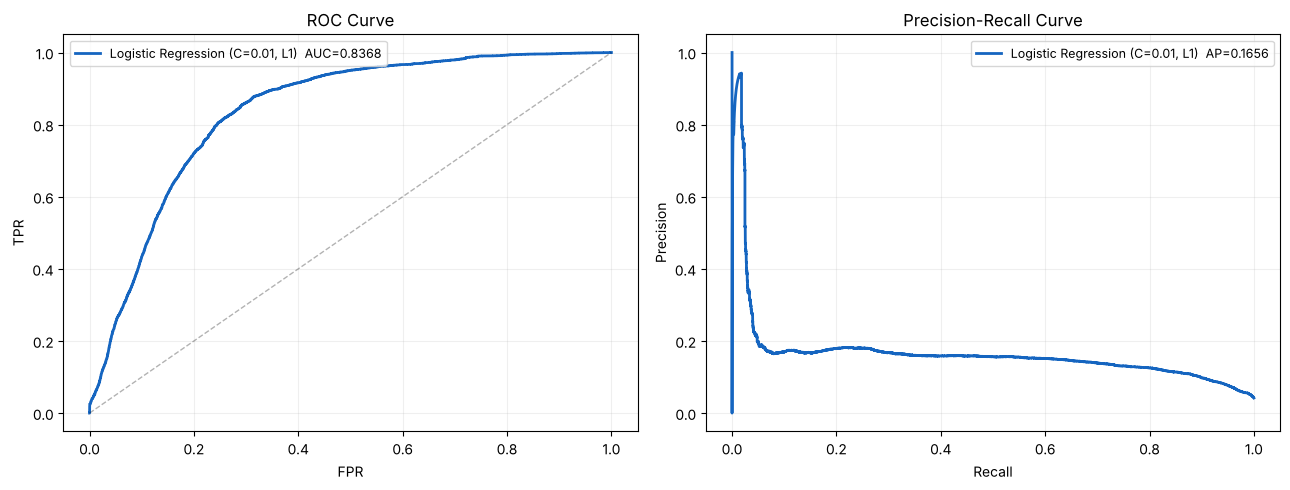

In [4]:
res = sp.evaluate('Logistic Regression (C=0.01, L1)', S['y_val'], m['val'], S['y_test'], m['test'])
sp.print_metrics(res)
sp.plot_curves([res])

## 4. Non-zero coefficients (L1 sparsity)

Non-zero coefficients: 51 / 62
                             Feature  Coefficient
                  n_eth_interactions    -1.146083
                           avg_depth     0.843941
                     l0_tx_time_span     0.833933
            gas_distribution_entropy     0.620916
                      balance_factor    -0.620463
                        time_span_in    -0.541166
       n_l0_project_per_source_chain    -0.422455
                    branching_factor    -0.390834
                 num_transactions_in     0.377688
           n_l0_to_eth_source_chains    -0.306543
               n_l0_source_contracts    -0.302249
 provider_total_gas_provision_amount     0.300735
                       n_l0_projects     0.278514
                   latest_l0_tx_time     0.264379
                        cex_in_count    -0.262077
                      breadth_factor    -0.228432
                  n_l0_source_chains     0.225667
              breadth_to_depth_ratio    -0.198348
               inde

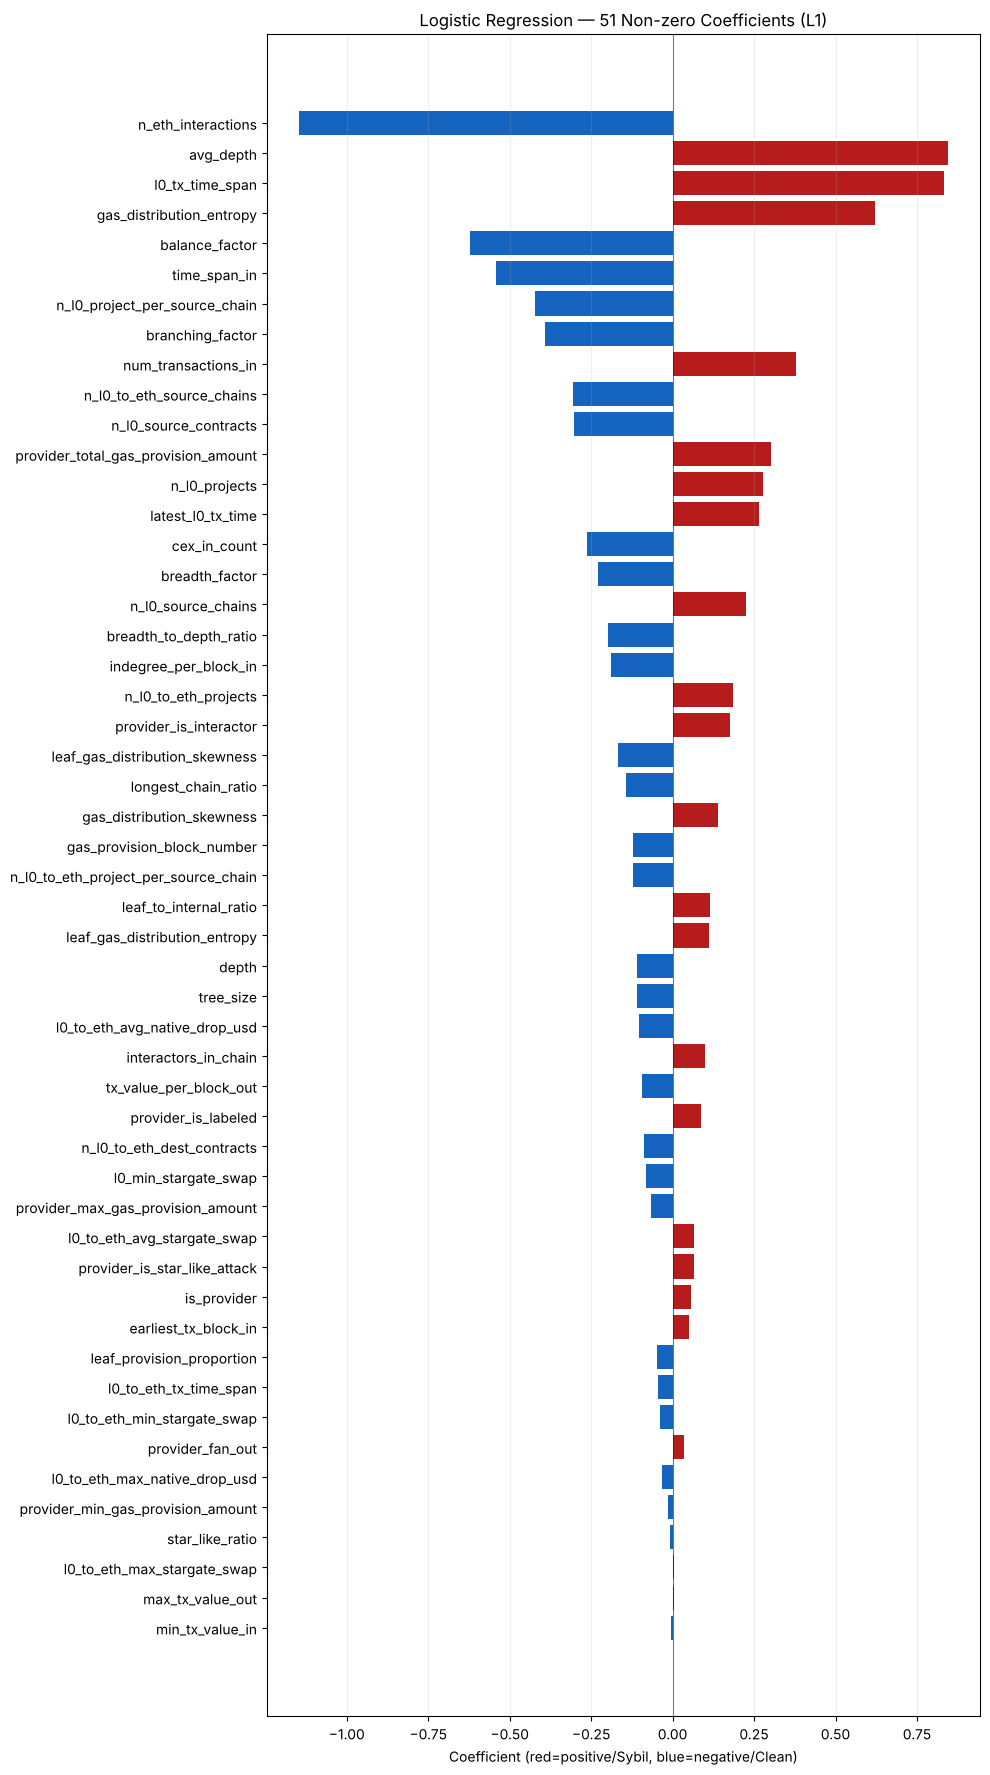

In [5]:
coef = m['model'].named_steps['lr'].coef_[0]
nz_df = pd.DataFrame([(f, c) for f, c in zip(FEATS, coef) if c != 0], columns=['Feature', 'Coefficient'])
nz_df = nz_df.reindex(nz_df['Coefficient'].abs().sort_values(ascending=False).index)
print(f'Non-zero coefficients: {len(nz_df)} / {len(FEATS)}')
print(nz_df.to_string(index=False))
fig, ax = plt.subplots(figsize=(10, max(5, len(nz_df) * 0.35)))
colors = ['#B71C1C' if v > 0 else '#1565C0' for v in nz_df['Coefficient']]
ax.barh(nz_df['Feature'][::-1], nz_df['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8, alpha=0.5)
ax.set(xlabel='Coefficient (red=positive/Sybil, blue=negative/Clean)',
       title=f'Logistic Regression — {len(nz_df)} Non-zero Coefficients (L1)')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout(); plt.show()

Logistic regression scores well below the gradient-boosted models on F1, although its AUROC is moderate;
it is included as a linear baseline, not as a deployment choice.

## Save results

Scalar metrics go to `results/05_logistic_regression_sybil.json` with the code commit, so every number in the paper can be traced
to one run. Validation and test probabilities go to `output/` for `06_cross_ensemble_sybil` and `10_tie_out`.

In [6]:
sp.save_results([res], '05_logistic_regression_sybil', leakage=leak, extra=dict(params=sp.LR_PARAMS))
sp.save_predictions(df, S, '05_logistic_regression_sybil', prob_lr=m)

Saved results/05_logistic_regression_sybil.json
Saved output/pred_05_logistic_regression_sybil_val.parquet (91,305 rows)


Saved output/pred_05_logistic_regression_sybil_test.parquet (130,435 rows)
